In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/rtl.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))

# فصل ۸ — یادگیری مبتنی بر نمونه
## درس ۲: انتخاب مقدار درست K

پارامتر $k$ مهم‌ترین پیچ تنظیم در یک طبقه‌بند K-Nearest Neighbors است. این پارامتر مشخص می‌کند مدل پیش از نسبت‌دادن یک کلاس، چه مقدار شواهد محلی گردآوری کند. با $k=1$، هر پیش‌بینی از یک مشاهدهٔ آموزش پیروی می‌کند و می‌تواند مرز تصمیم بسیار پرجزئیاتی بسازد. با $k$ بسیار بزرگ‌تر، هر پیش‌بینی روی همسایگی وسیع‌تری میانگین می‌گیرد و تصمیم‌های هموارتر می‌سازد. هیچ‌یک از این دو حد به‌طور خودکار درست نیست. مقدار مفید به اندازهٔ نمونه، هم‌پوشانی کلاس‌ها، نویز، نمایش ویژگی‌ها، معیار فاصله و هزینهٔ خطاهای مختلف بستگی دارد.

این درس روشی قابل دفاع برای انتخاب $k$ می‌سازد. مقدار را با نگاه‌کردن به یک امتیاز آزمون تنها انتخاب نمی‌کنیم و به شعارهایی مانند همیشه عدد فرد بگیر تکیه نمی‌کنیم. در عوض، هدف ارزیابی را تعریف می‌کنیم، یک مجموعهٔ آزمون نهایی را جدا می‌کنیم، روی دادهٔ آموزش از اعتبارسنجی متقابل stratified استفاده می‌کنیم، هم میانگین و هم تغییرپذیری امتیاز را می‌بینیم، نامزدهای نزدیک را مقایسه می‌کنیم و در پایان pipeline انتخاب‌شده را فقط یک‌بار روی دادهٔ کنارگذاشته‌شده ارزیابی می‌کنیم. این فرایند از هر عدد برنده‌ای مهم‌تر است.

مثال اصلی ما از glass.csv در این مخزن استفاده می‌کند. سطرهای آن اندازه‌گیری‌های عددی شیمیایی و نوری دارند و Type برچسب چندکلاسه است. توزیع کلاس‌ها نامتوازن است، بنابراین macro F1 از دقت معمولی به‌تنهایی آگاه‌کننده‌تر است. مثال دوم از Wine_Quality.csv استفاده می‌کند و از ستون عددی quality یک هدف دودویی می‌سازد. این مثال نشان می‌دهد عادت‌های انتخاب یکسان، وقتی تعریف برچسب و معیار کسب‌وکار عوض می‌شود نیز کار می‌کنند.

### هدف‌های یادگیری

در پایان این درس باید بتوانید:

1. توضیح دهید $k$ چگونه مصالحهٔ بایاس-واریانس را در KNN تغییر می‌دهد.
2. یک پروتکل آموزش/آزمون بسازید که مجموعهٔ آزمون نهایی را از انتخاب hyperparameter محافظت کند.
3. با اعتبارسنجی متقابل stratified بازه‌ای از مقدارهای $k$ را مقایسه کنید.
4. معیار امتیازدهی متناسب با توازن کلاس‌ها و هدف عملی را انتخاب کنید.
5. منحنی اعتبارسنجی را با میانگین و تغییرپذیری آن تفسیر کنید، نه فقط با بیشینهٔ آن.
6. با GridSearchCV مقیاس‌بندی و انتخاب را در یک pipeline بازتولیدپذیر نگه دارید.
7. مقدارهای نزدیک $k$، قانون رأی و معیارهای فاصله را بدون نشت مجموعهٔ آزمون مقایسه کنید.
8. عملکرد نهایی دادهٔ کنارگذاشته‌شده را صادقانه گزارش کنید و تشخیص دهید چه زمانی یک تفاوت بیش از حد کوچک است.

پس عبارت مقدار درست K را باید با دقت خواند. معمولاً یک مقدار برتر همیشگی وجود ندارد. یک مقدار یا ناحیهٔ کوچکِ پایداری وجود دارد که با دادهٔ آموزش موجود و یک قانون ارزیابی انتخاب‌شده خوب پشتیبانی می‌شود. دادهٔ جدید، مجموعه‌ویژگی متفاوت یا هزینهٔ خطای دیگر می‌تواند این نتیجه را تغییر دهد.

## ۱. چرا $k$ رفتار مدل را تغییر می‌دهد

برای مشاهدهٔ پرس‌وجو $x_*$، KNN مجموعهٔ $N_k(x_*)$، یعنی $k$ مثال آموزشی نزدیک‌تر را پیدا می‌کند. طبقه‌بندی یکنواخت کلاسی را انتخاب می‌کند که بیشترین شمارش را در این همسایگی دارد:

$$
\hat{y}(x_*)=\operatorname*{arg\,max}_{c\in\mathcal{C}}\sum_{i\in N_k(x_*)}\mathbb{1}(y_i=c).
$$

وقتی $k$ کوچک است، همسایگی باریک است. مدل می‌تواند با الگوهای محلی ظریف سازگار شود، اما یک نقطهٔ پرت یا برچسب اشتباه می‌تواند بر پیش‌بینی مسلط شود. این حالت را معمولاً بایاس کم و واریانس زیاد می‌نامند: قانون تصمیم شکل‌های پیچیده را برازش می‌کند، اما با تغییر نمونهٔ آموزش به‌طور محسوس عوض می‌شود. وقتی $k$ بزرگ است، همسایگی مشاهده‌ها را از ناحیهٔ گسترده‌تری مخلوط می‌کند. مرز به‌دست‌آمده هموارتر و نسبت به سطرهای منفرد کم‌حساس‌تر است، اما ممکن است ناحیهٔ کوچک یک کلاس را محو کند. این حالت بایاس بیشتر و واریانس کمتر است.

شهود رایج استفاده از $k$ فرد برای کاهش رأی مساوی در طبقه‌بندی دودویی است. این فقط یک قرارداد مناسب است، نه روش انتخاب. در طبقه‌بندی چندکلاسه، با وزن‌های فاصله یا در حضور چند برچسب در همسایگی هنوز تساوی رخ می‌دهد. مهم‌تر از آن، یک مقدار فرد همچنان می‌تواند بیش از حد محلی یا بیش از حد سراسری باشد. شواهد اعتبارسنجی باید مقیاس همسایگی را انتخاب کنند.

## ۲. پروتکل انتخاب بدون نشت اطلاعات

انتخاب hyperparameter شکلی از یادگیری است. اگر مقدارهای زیادی از $k$ را امتحان کنیم و مقدار با بالاترین امتیاز آزمون را نگه داریم، مجموعهٔ آزمون در انتخاب مدل کمک کرده است. در این صورت امتیاز گزارش‌شده خوش‌بینانه است، زیرا هم تعمیم و هم انتخاب‌های خوش‌شانس میان نامزدها را بازتاب می‌دهد. راه‌حل جریان کاری سه‌بخشی است: یک‌بار مجموعهٔ آزمون را کنار بگذارید، پیکربندی‌ها را فقط در مجموعهٔ آموزش مقایسه کنید و پیکربندی انتخاب‌شده را یک‌بار روی آزمون ارزیابی کنید.

اعتبارسنجی متقابل مقایسه را کارآمدتر می‌کند. در اعتبارسنجی متقابل stratified با $r$ fold، مجموعهٔ آموزش به $r$ بخش تقسیم می‌شود که تا حد ممکن نسبت کلاس‌ها را حفظ می‌کنند. هر نامزد $k$ روی $r-1$ fold برازش و روی fold باقی‌مانده امتیازدهی می‌شود و این فرایند می‌چرخد تا همهٔ foldها نقش اعتبارسنجی داشته باشند. میانگین، عملکرد اعتبارسنجی مورد انتظار را برآورد می‌کند و انحراف معیار نشان می‌دهد نتیجه میان foldها چقدر تغییر می‌کند.

تمام پیش‌پردازش باید داخل حلقهٔ اعتبارسنجی متقابل باشد. StandardScaler میانگین و انحراف معیار را برآورد می‌کند، پس باید آن‌ها را فقط از هر fold آموزش یاد بگیرد. Pipeline این کار را خودکار انجام می‌دهد. برازش scaler پیش از اعتبارسنجی متقابل اجازه می‌دهد اطلاعات سطرهای اعتبارسنجی بر نمایش خودشان اثر بگذارد که شکل ظریفی از نشت است.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score, make_scorer, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold, StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")
macro_f1 = make_scorer(f1_score, average="macro", zero_division=0, pos_label=None)

## ۳. پیش از انتخاب معیار، glass.csv را بررسی کنید

سطرهای نخست glass.csv نشان می‌دهند RI، Na، Mg، Al، Si، K، Ca، Ba و Fe ویژگی‌های عددی هستند. Type هدف دسته‌ای است. چون همهٔ ستون‌های پیش‌بینی‌کننده اندازه‌گیری‌اند، فاصلهٔ اقلیدسی و منهتن پس از مقیاس‌بندی نقطهٔ آغاز معناداری هستند. مقدارها همچنان دامنه‌های متفاوتی دارند، بنابراین فاصلهٔ خام به ستون‌های با واریانس بالا مانند Ca یا Na اثر نامتناسب می‌دهد.

هدف چندین دستهٔ شیشه دارد و فراوانی آن‌ها برابر نیست. دقت هر پیش‌بینی درست را یکسان می‌شمارد و می‌تواند زیر اثر کلاس‌های پرتکرار قرار گیرد. Macro F1 برای هر کلاس یک F1 محاسبه و بدون وزن‌دهی بر اساس فراوانی کلاس‌ها میانگین می‌گیرد. در نتیجه کلاس‌های نادر نیز در انتخاب مدل اثر دارند. این معیار برای همهٔ کاربردها به‌صورت جادویی درست نیست، اما وقتی هر نوع شیشه شایستهٔ توجه است انتخابی اندیشیده‌شده است.

In [3]:
glass_path = Path("../../../Datasets/Classification/glass.csv")
glass_df = pd.read_csv(glass_path)
glass_target = "Type"
glass_features = [column for column in glass_df.columns if column != glass_target]
glass_X = glass_df[glass_features]
glass_y = glass_df[glass_target]

display(glass_df.head())
display(glass_df.dtypes.rename("dtype").to_frame())
display(glass_y.value_counts().rename("count").to_frame())

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,building_windows_float_processed
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,building_windows_float_processed
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,building_windows_float_processed
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,building_windows_float_processed
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,building_windows_float_processed


,dtype
RI,float64
Na,float64
Mg,float64
Al,float64
Si,float64
K,float64
Ca,float64
Ba,float64
Fe,float64
Type,object


,count
Type,
building_windows_non_float_processed,76
building_windows_float_processed,70
headlamps,29
vehicle_windows_float_processed,17
containers,13
tableware,9


## ۴. یک مجموعهٔ آزمون نهایی کنار بگذارید

پیش از مقایسهٔ مقدارهای $k$، 25% داده را به‌عنوان مجموعهٔ آزمون نهایی کنار می‌گذاریم. تقسیم stratified است تا نوع‌های کم‌فراوان شیشه تا حد ممکن در هر دو بخش حضور داشته باشند. سطرهای آزمون در نمودارهای اعتبارسنجی متقابل یا نتیجه‌های GridSearchCV ظاهر نمی‌شوند. آن‌ها تا یک ارزیابی نهایی پس از انتخاب پیکربندی نگه داشته می‌شوند.

برای این داده به‌جای پنج fold از سه fold استفاده می‌کنیم. بعضی کلاس‌ها کوچک‌اند و تقسیم stratified سه‌تایی به هر fold آموزش نمونهٔ کافی از کلاس‌های نادرتر می‌دهد. تعداد fold یک آیین نیست. fold بیشتر ممکن است بایاس برآورد اعتبارسنجی را کم کند، اما foldها را شبیه‌تر می‌کند و وقتی کلاس نادر نمونهٔ کم دارد حتی ناممکن است. تقسیم باید به دادهٔ واقعی احترام بگذارد.

In [4]:
glass_X_train, glass_X_test, glass_y_train, glass_y_test = train_test_split(glass_X, glass_y, test_size=0.25, stratify=glass_y, random_state=RANDOM_STATE)
glass_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
split_summary = pd.DataFrame({"subset": ["training", "test"], "rows": [len(glass_X_train), len(glass_X_test)], "classes": [glass_y_train.nunique(), glass_y_test.nunique()]})
display(split_summary)
display(pd.crosstab(index=glass_y, columns="full_data", normalize="columns").join(pd.crosstab(index=glass_y_train, columns="training", normalize="columns"), how="outer").join(pd.crosstab(index=glass_y_test, columns="test", normalize="columns"), how="outer").fillna(0).round(3))

,subset,rows,classes
0,training,160,6
1,test,54,6


col_0,full_data,training,test
Type,,,
building_windows_float_processed,0.327,0.325,0.333
building_windows_non_float_processed,0.355,0.356,0.352
containers,0.061,0.062,0.056
headlamps,0.136,0.131,0.148
tableware,0.042,0.044,0.037
vehicle_windows_float_processed,0.079,0.081,0.074


## ۵. برای $k$ یک منحنی اعتبارسنجی بسازید

یک منحنی اعتبارسنجی مقدارهای نامزد را با foldهای یکسان و تابع امتیازدهی یکسان مقایسه می‌کند. مقدارهای فرد 1 تا 31 را جست‌وجو می‌کنیم. قرارداد عدد فرد فقط یک شبکهٔ اولیهٔ مرتب است؛ اعتبارسنجی متقابل تعیین می‌کند کدام مقدارها پشتیبانی می‌شوند. pipeline نامزد، اندازه‌گیری‌های عددی را استاندارد و سپس KNN را اعمال می‌کند. scaler در هر fold دوباره برازش می‌شود تا سطرهای اعتبارسنجی در میانگین یا انحراف معیار fold آموزش مشارکت نکنند.

نمودار را به‌عنوان ناحیه‌ای از شواهد بخوانید، نه مسابقهٔ اسب‌دوانی. یک بیشینهٔ منفرد ممکن است حاصل fold خوش‌شانس باشد. اگر چند مقدار همسایه میانگین macro F1 تقریباً برابر و تغییرپذیری هم‌پوشان داشته باشند، تفسیر پایدارتر یا ساده‌تر را ترجیح دهید. برای KNN، مقدار کمی بزرگ‌تر از $k$ می‌تواند وقتی عملکرد را نگه می‌دارد و حساسیت به یک سطر غیرعادی را کم می‌کند جذاب باشد.

,k,mean_macro_f1,std_macro_f1
0,1,0.578,0.089
2,5,0.514,0.108
1,3,0.490,0.054
3,7,0.434,0.051
4,9,0.410,0.034
5,11,0.389,0.012
6,13,0.368,0.017
7,15,0.360,0.012


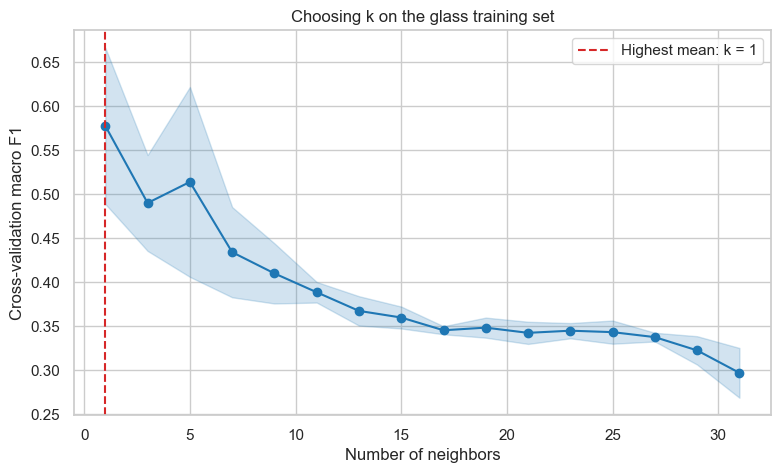

In [5]:
k_candidates = list(range(1, 32, 2))
curve_rows = []
for k_value in k_candidates:
    candidate = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k_value, weights="uniform", p=2))
    scores = cross_val_score(candidate, glass_X_train, glass_y_train, cv=glass_cv, scoring=macro_f1, error_score="raise")
    curve_rows.append({"k": k_value, "mean_macro_f1": scores.mean(), "std_macro_f1": scores.std()})
k_curve = pd.DataFrame(curve_rows)
best_k_by_mean = int(k_curve.loc[k_curve["mean_macro_f1"].idxmax(), "k"])
display(k_curve.sort_values("mean_macro_f1", ascending=False).head(8).round(3))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_curve["k"], k_curve["mean_macro_f1"], marker="o", color="tab:blue")
ax.fill_between(k_curve["k"], k_curve["mean_macro_f1"] - k_curve["std_macro_f1"], k_curve["mean_macro_f1"] + k_curve["std_macro_f1"], color="tab:blue", alpha=0.2)
ax.axvline(best_k_by_mean, color="tab:red", linestyle="--", label=f"Highest mean: k = {best_k_by_mean}")
ax.set_xlabel("Number of neighbors")
ax.set_ylabel("Cross-validation macro F1")
ax.set_title("Choosing k on the glass training set")
ax.legend()
plt.show()

## ۶. پایداری به اندازهٔ اوج امتیاز مهم است

منحنی سه‌تایی تنها از سه بخش اعتبارسنجی استفاده می‌کند، پس ممکن است زیر اثر یک fold خوش‌شانس یا دشوار باشد. اعتبارسنجی متقابل stratified تکرارشونده، بخش‌بندی را با چند shuffle تصادفی تکرار می‌کند. این کار اطلاعات جدید تولید نمی‌کند، اما دید گسترده‌تری از رفتار هر نامزد در تقسیم‌های قابل‌قبول دادهٔ آموزش فراهم می‌کند. نامزدی با میانگین اندکی پایین‌تر اما تغییرپذیری کم‌تر می‌تواند انتخاب عملی قابل‌اعتمادتری باشد.

هیچ قانون همگانی نمی‌گوید یک انحراف معیار همه‌چیز را تعیین می‌کند. امتیازها میان foldها هم‌بسته‌اند و مدل‌های مختلف روی داده‌های مرتبط ارزیابی می‌شوند. با این حال، تغییرپذیری از اعتمادبه‌نفس بیش از حد جلوگیری می‌کند. بهبود کوچکی مانند 0.002 در macro F1 ممکن است از مدلی که پایدار، تفسیرپذیر و به‌اندازهٔ کافی سریع است کم‌اهمیت‌تر باشد.

In [6]:
repeated_cv = RepeatedStratifiedKFold(n_splits=3, n_repeats=3, random_state=RANDOM_STATE)
stability_candidates = sorted(set([max(1, best_k_by_mean - 2), best_k_by_mean, best_k_by_mean + 2, best_k_by_mean + 4]))
stability_rows = []
for k_value in stability_candidates:
    stability_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k_value, weights="uniform"))
    stability_scores = cross_val_score(stability_model, glass_X_train, glass_y_train, cv=repeated_cv, scoring=macro_f1, error_score="raise")
    stability_rows.append({"k": k_value, "mean_macro_f1": stability_scores.mean(), "std_macro_f1": stability_scores.std(), "minimum_fold_score": stability_scores.min(), "maximum_fold_score": stability_scores.max()})
stability_results = pd.DataFrame(stability_rows).sort_values("k")
display(stability_results.round(3))

,k,mean_macro_f1,std_macro_f1,minimum_fold_score,maximum_fold_score
0,1,0.562,0.082,0.415,0.665
1,3,0.482,0.084,0.362,0.663
2,5,0.466,0.112,0.271,0.618


## ۷. یک راه‌شکن عملی: همسایگی پایدار را انتخاب کنید

وقتی چند مقدار رقابتی‌اند، ایدهٔ یک خطای استاندارد راهنمای مفیدی است. ابتدا نامزدی را با بزرگ‌ترین میانگین امتیاز اعتبارسنجی بیابید. سپس آستانه‌ای برابر با یک انحراف معیار برآوردشده پایین‌تر از آن امتیاز محاسبه کنید. میان نامزدهای بالای آستانه، به‌جای کوچک‌ترین همسایگی ممکن، مقداری از $k$ را انتخاب کنید که هموارسازی بیشتری دارد. این قضیهٔ ریاضی نیست و باید به‌عنوان یک heuristic گزارش شود، اما از انتخاب مدل بیش از حد محلی برای یک سود کوچک و شکننده جلوگیری می‌کند.

برای KNN، انتخاب بزرگ‌ترین $k$ واجد شرایط راهی شفاف برای ترجیح قانون تصمیم هموارتر است. در موقعیتی که الگوهای محلی نادر حیاتی‌اند، ممکن است پس از بازبینی دامنه مقدار کوچک‌تری را ترجیح دهید. نکتهٔ اصلی این است که سیاست را پیش از دیدن نتیجهٔ آزمون بیان کنید و مجموعهٔ آزمون را بیرون از تصمیم نگه دارید.

In [7]:
best_mean = k_curve["mean_macro_f1"].max()
best_std = k_curve.loc[k_curve["mean_macro_f1"].idxmax(), "std_macro_f1"]
one_se_threshold = best_mean - best_std
eligible_k = k_curve.loc[k_curve["mean_macro_f1"] >= one_se_threshold, "k"]
selected_k = int(eligible_k.max())
selection_table = k_curve.assign(within_one_standard_deviation=k_curve["mean_macro_f1"] >= one_se_threshold)
display(selection_table.sort_values("k").round(3))
print(f"Highest-mean k: {best_k_by_mean}")
print(f"One-standard-deviation threshold: {one_se_threshold:.3f}")
print(f"Selected stable k: {selected_k}")

,k,mean_macro_f1,std_macro_f1,within_one_standard_deviation
0,1,0.578,0.089,True
1,3,0.490,0.054,True
2,5,0.514,0.108,True
3,7,0.434,0.051,False
4,9,0.410,0.034,False
5,11,0.389,0.012,False
6,13,0.368,0.017,False
7,15,0.360,0.012,False
8,17,0.346,0.005,False
9,19,0.349,0.011,False


Highest-mean k: 1
One-standard-deviation threshold: 0.489
Selected stable k: 5


## ۸. برای انتخاب قابل ممیزی از GridSearchCV استفاده کنید

حلقه‌های دستی برای یادگیری و دیدن منحنی عالی‌اند. برای آزمایشی بازتولیدپذیر، GridSearchCV شبکهٔ نامزدها، قانون امتیازدهی، foldها، بهترین پارامترها و بهترین estimator برازش‌شده را در یک شیء ثبت می‌کند. شبکهٔ کوچکی روی $k$، وزن رأی و پارامتر فاصلهٔ Minkowski یعنی $p$ جست‌وجو می‌کنیم. در این‌جا $p=1$ فاصلهٔ منهتن و $p=2$ فاصلهٔ اقلیدسی است.

این یک مسئلهٔ انتخاب مشترک است. مقدار ترجیحی $k$ می‌تواند با تغییر معیار یا قانون وزن عوض شود، زیرا همسایگی مؤثر تغییر می‌کند. جست‌وجوی مستقل هر انتخاب و ترکیب برنده‌ها در پایان می‌تواند گمراه‌کننده باشد. pipeline مقیاس‌بندی را درون هر fold نگه می‌دارد و grid search فقط از glass_X_train و glass_y_train استفاده می‌کند.

In [8]:
search_pipeline = make_pipeline(StandardScaler(), KNeighborsClassifier())
parameter_grid = {"kneighborsclassifier__n_neighbors": [3, 5, 7, 9, 11, 15, 21], "kneighborsclassifier__weights": ["uniform", "distance"], "kneighborsclassifier__p": [1, 2]}
grid_search = GridSearchCV(search_pipeline, parameter_grid, scoring=macro_f1, cv=glass_cv, n_jobs=1, return_train_score=True, refit=True, error_score="raise")
grid_search.fit(glass_X_train, glass_y_train)
grid_results = pd.DataFrame(grid_search.cv_results_)
display(grid_results[["param_kneighborsclassifier__n_neighbors", "param_kneighborsclassifier__weights", "param_kneighborsclassifier__p", "mean_test_score", "std_test_score", "mean_train_score", "rank_test_score"]].sort_values("rank_test_score").head(10).round(3))
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation macro F1: {grid_search.best_score_:.3f}")

,param_kneighborsclassifier__n_neighbors,param_kneighborsclassifier__weights,param_kneighborsclassifier__p,mean_test_score,std_test_score,mean_train_score,rank_test_score
5,5,distance,1,0.624,0.048,1.000,1
1,3,distance,1,0.620,0.033,1.000,2
3,3,distance,2,0.565,0.057,1.000,3
9,7,distance,1,0.554,0.051,1.000,4
0,3,uniform,1,0.545,0.049,0.781,5
4,5,uniform,1,0.516,0.028,0.670,6
6,5,uniform,2,0.514,0.108,0.595,7
7,5,distance,2,0.511,0.041,1.000,8
17,11,distance,1,0.496,0.037,1.000,9
2,3,uniform,2,0.490,0.054,0.718,10


Best parameters: {'kneighborsclassifier__n_neighbors': 5, 'kneighborsclassifier__p': 1, 'kneighborsclassifier__weights': 'distance'}
Best cross-validation macro F1: 0.624


## ۹. مدل انتخاب‌شده را یک‌بار روی دادهٔ کنارگذاشته‌شده ارزیابی کنید

تنها اکنون از مجموعهٔ آزمون glass استفاده می‌کنیم. بهترین estimator برازش‌شدهٔ GridSearchCV از پیش شامل scaler و طبقه‌بند KNN آموزش‌دیده بر همهٔ سطرهای آموزش است. دقت را برای خلاصهٔ کلی آشنا، macro F1 را برای عملکرد متوازن کلاس‌ها، گزارش طبقه‌بندی و ماتریس درهم‌ریختگی گزارش می‌کنیم. امتیاز آزمون ممکن است پایین‌تر یا بالاتر از اعتبارسنجی متقابل باشد. این تفاوت تغییر نمونه‌گیری عادی است، نه نشانه‌ای که باید به شبکه بازگردیم و در برابر سطرهای آزمون تنظیم کنیم.

هنگام خواندن ماتریس درهم‌ریختگی به دسته‌هایی نگاه کنید که پیوسته با هم اشتباه می‌شوند. امتیاز پایین یک کلاس نادر ممکن است بازتاب نمونه‌های آموزشی محدود، هم‌پوشانی شیمیایی یا ویژگی‌های ناکافی باشد. تغییر $k$ تنها پاسخ ممکن نیست. اندازه‌گیری بهتر، مثال‌های بیشتر، تعریف فاصلهٔ متفاوت، وزن‌دهی کلاس در خانوادهٔ مدل دیگر یا زیان مسئله‌محور ممکن است مهم‌تر باشد.

,metric,test_value
0,accuracy,0.815
1,macro_f1,0.745


,precision,recall,f1-score,support
building_windows_float_processed,0.750,0.833,0.789,18.000
building_windows_non_float_processed,0.810,0.895,0.850,19.000
containers,1.000,1.000,1.000,3.000
headlamps,1.000,0.875,0.933,8.000
tableware,0.500,0.500,0.500,2.000
vehicle_windows_float_processed,1.000,0.250,0.400,4.000
accuracy,0.815,0.815,0.815,0.815
macro avg,0.843,0.726,0.745,54.000
weighted avg,0.831,0.815,0.804,54.000


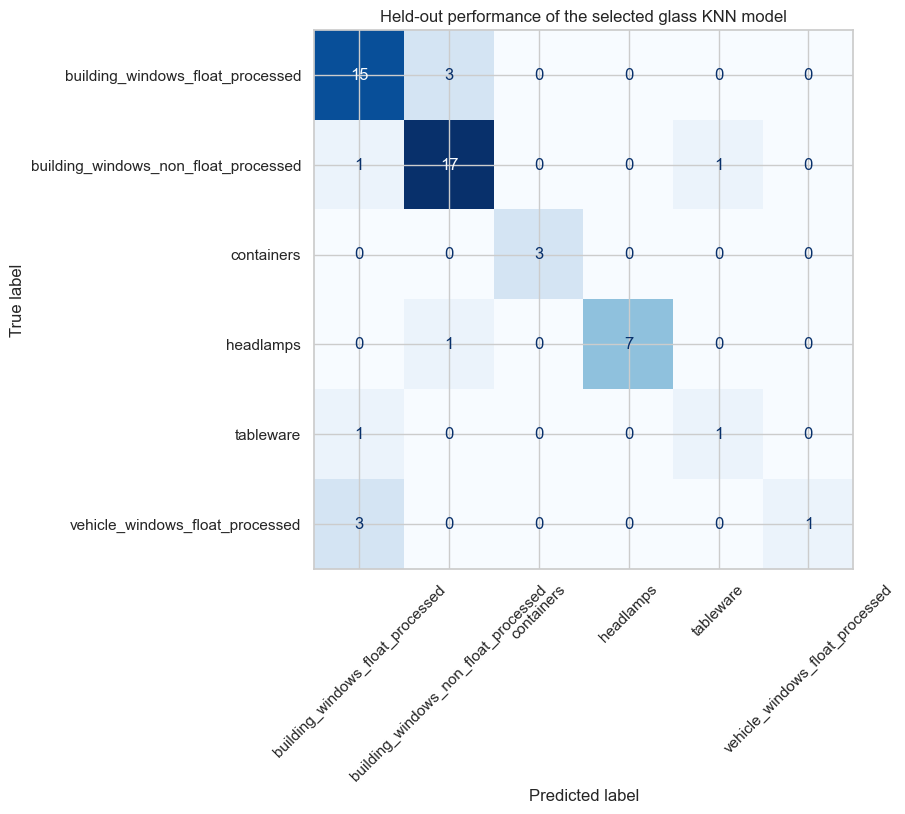

In [9]:
glass_test_predictions = grid_search.predict(glass_X_test)
glass_test_accuracy = accuracy_score(glass_y_test, glass_test_predictions)
glass_test_macro_f1 = f1_score(glass_y_test, glass_test_predictions, average="macro", zero_division=0)
final_metrics = pd.DataFrame({"metric": ["accuracy", "macro_f1"], "test_value": [glass_test_accuracy, glass_test_macro_f1]})
display(final_metrics.round(3))
display(pd.DataFrame(classification_report(glass_y_test, glass_test_predictions, output_dict=True, zero_division=0)).T.round(3))

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(glass_y_test, glass_test_predictions, xticks_rotation=45, cmap="Blues", colorbar=False, ax=ax)
ax.set_title("Held-out performance of the selected glass KNN model")
plt.show()

## ۱۰. مجموعه‌دادهٔ دوم: تعریف هدف، هدف انتخاب را عوض می‌کند

Wine_Quality.csv اندازه‌گیری‌های عددی شیمیایی و یک امتیاز کیفیت صحیح دارد. سطرهای نخست تأیید می‌کنند ستون‌های پیش‌بینی‌کننده عددی‌اند. برای نمونهٔ فشردهٔ طبقه‌بندی، یک هدف دودویی تعریف می‌کنیم: کیفیت 6 یا بیش‌تر Higher quality و امتیازهای کم‌تر Lower quality هستند. این تبدیل یک انتخاب مدل‌سازی است، نه کشف یک آستانهٔ همگانی. در پروژهٔ واقعی، تعریف هدف باید از نیازهای دامنه و پیامدهای مثبت کاذب و منفی کاذب پیروی کند.

هدف این مثال دوم ادعا دربارهٔ کارکرد یک مقدار $k$ در همه‌جا نیست. از دادهٔ متفاوت، تعریف کلاس متفاوت و معیار انتخاب متفاوت استفاده می‌کنیم. چون کلاس‌های تبدیل‌شده دودویی‌اند، ROC AUC در کنار دقت مفید است. AUC رتبه‌بندی را در آستانه‌های احتمال ارزیابی می‌کند، اما دقت برچسب‌ها را در قانون تصمیم پیش‌فرض طبقه‌بند می‌سنجد.

In [10]:
wine_path = Path("../../../Datasets/Classification/Wine_Quality.csv")
wine_df = pd.read_csv(wine_path)
wine_X = wine_df.drop(columns="quality")
wine_y = np.where(wine_df["quality"] >= 6, "Higher quality", "Lower quality")

display(wine_df.head())
display(wine_df.dtypes.rename("dtype").to_frame())
display(pd.Series(wine_y, name="quality_group").value_counts().rename("count").to_frame())

wine_X_train, wine_X_test, wine_y_train, wine_y_test = train_test_split(wine_X, wine_y, test_size=0.25, stratify=wine_y, random_state=RANDOM_STATE)
wine_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


,dtype
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


,count
quality_group,
Higher quality,3258
Lower quality,1640


## ۱۱. $k$ را روی مجموعهٔ آموزش wine مقایسه کنید

دوباره بازه‌ای از مقدارها را مقایسه می‌کنیم، اما این‌بار ROC AUC را به کار می‌بریم. احتمال‌های KNN بر پایهٔ نسبت رأی‌های محلی‌اند، بنابراین حتی پیش از انتخاب آستانهٔ کلاس می‌توانند برای رتبه‌بندی مشاهده‌ها استفاده شوند. $k$ انتخاب‌شده فقط از foldهای آموزش wine به‌دست می‌آید. مجموعهٔ آزمون wine تا سلول بعدی دیده نمی‌شود.

دقت کنید AUC بالا بهترین احتمال کالیبره‌شده یا بهترین آستانهٔ تصمیم را تضمین نمی‌کند. این معیار می‌گوید موردهای مثبت معمولاً امتیاز بالاتری از موردهای منفی می‌گیرند. اگر هدف عملی یک آستانهٔ ثابت با هزینه‌های نامتقارن است، معیار و آستانه‌ای انتخاب کنید که همان هزینه‌ها را بازتاب دهد. انتخاب مدل همواره به تصمیمی که پشتیبانی می‌کند گره خورده است.

,k,mean_roc_auc,std_roc_auc
14,29,0.887,0.010
15,31,0.887,0.010
13,27,0.887,0.010
12,25,0.886,0.009
11,23,0.885,0.010
10,21,0.885,0.009
9,19,0.884,0.009
8,17,0.884,0.008


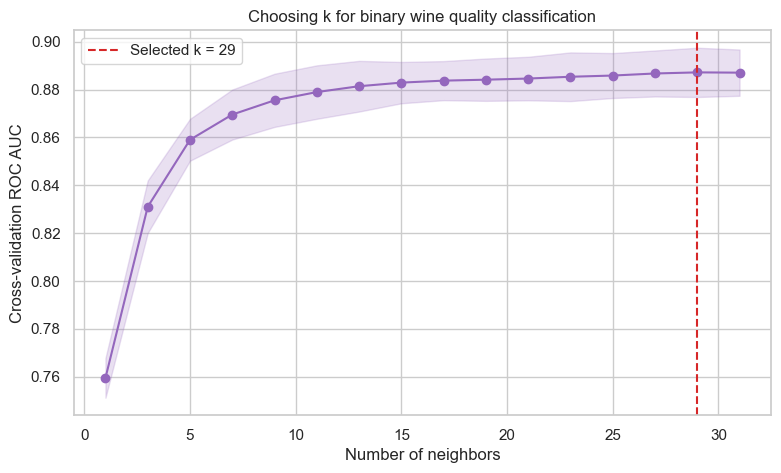

In [11]:
wine_rows = []
for k_value in range(1, 32, 2):
    wine_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k_value, weights="distance"))
    wine_scores = cross_val_score(wine_model, wine_X_train, wine_y_train, cv=wine_cv, scoring="roc_auc", error_score="raise")
    wine_rows.append({"k": k_value, "mean_roc_auc": wine_scores.mean(), "std_roc_auc": wine_scores.std()})
wine_curve = pd.DataFrame(wine_rows)
wine_best_k = int(wine_curve.loc[wine_curve["mean_roc_auc"].idxmax(), "k"])
display(wine_curve.sort_values("mean_roc_auc", ascending=False).head(8).round(3))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(wine_curve["k"], wine_curve["mean_roc_auc"], marker="o", color="tab:purple")
ax.fill_between(wine_curve["k"], wine_curve["mean_roc_auc"] - wine_curve["std_roc_auc"], wine_curve["mean_roc_auc"] + wine_curve["std_roc_auc"], alpha=0.2, color="tab:purple")
ax.axvline(wine_best_k, color="tab:red", linestyle="--", label=f"Selected k = {wine_best_k}")
ax.set_xlabel("Number of neighbors")
ax.set_ylabel("Cross-validation ROC AUC")
ax.set_title("Choosing k for binary wine quality classification")
ax.legend()
plt.show()

## ۱۲. ارزیابی نهایی wine و منحنی احتمال

pipeline انتخاب‌شدهٔ wine را روی همهٔ سطرهای آموزش برازش می‌دهیم و برای سطرهای آزمون کنارگذاشته‌شده احتمال پیش‌بینی می‌کنیم. منحنی ROC نرخ مثبت واقعی را در برابر نرخ مثبت کاذب در آستانه‌های گوناگون رسم می‌کند. خط قطری مرجع متناظر با رتبه‌بندی تصادفی است. نتیجه یک ارزیابی نهایی از یک مسیر انتخاب است و نباید برای شروع دوبارهٔ جست‌وجو استفاده شود.

این مثال دوباره تأکید می‌کند که انتخاب $k$ از نتیجهٔ مورد نظر جدا نیست. در glass با macro F1 از کلاس‌های اقلیت محافظت کردیم. در wine رتبه‌بندی را با ROC AUC دیدیم. کاربرد تولیدی ممکن است recall در precision ثابت، هزینهٔ مورد انتظار، خطای کالیبراسیون یا حجم کار بازبینی انسانی را ترجیح دهد. مقدار درست K فقط نسبت به هدف کامل مدل‌سازی درست است.

,metric,test_value
0,accuracy,0.826
1,roc_auc,0.913


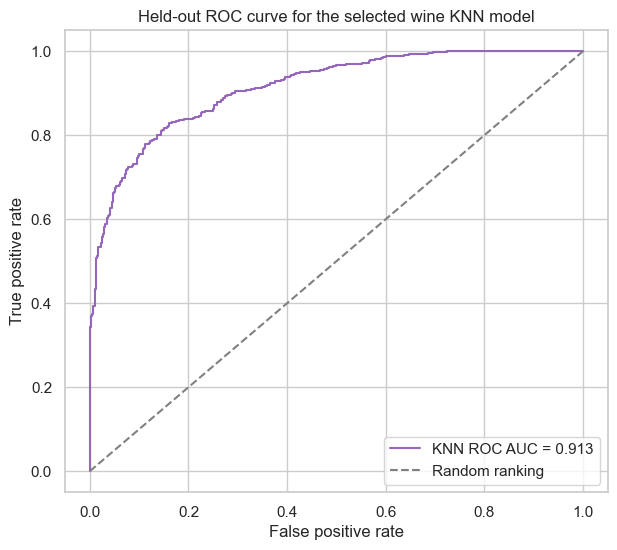

In [12]:
wine_selected_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=wine_best_k, weights="distance"))
wine_selected_model.fit(wine_X_train, wine_y_train)
wine_test_predictions = wine_selected_model.predict(wine_X_test)
wine_probability_index = list(wine_selected_model.classes_).index("Higher quality")
wine_test_probabilities = wine_selected_model.predict_proba(wine_X_test)[:, wine_probability_index]
wine_test_auc = roc_auc_score(wine_y_test == "Higher quality", wine_test_probabilities)
wine_test_accuracy = accuracy_score(wine_y_test, wine_test_predictions)
wine_fpr, wine_tpr, _ = roc_curve(wine_y_test == "Higher quality", wine_test_probabilities)
display(pd.DataFrame({"metric": ["accuracy", "roc_auc"], "test_value": [wine_test_accuracy, wine_test_auc]}).round(3))

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(wine_fpr, wine_tpr, label=f"KNN ROC AUC = {wine_test_auc:.3f}", color="tab:purple")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random ranking")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Held-out ROC curve for the selected wine KNN model")
ax.legend()
plt.show()

## ۱۳. خطاهای رایج در انتخاب $k$

از این خطاهای پرتکرار دوری کنید:

1. انتخاب $k$ از امتیاز آزمون و سپس گزارش همان امتیاز به‌عنوان عملکرد نهایی.
2. مقیاس‌بندی کل داده پیش از تقسیم یا اعتبارسنجی متقابل.
3. استفاده از دقت به‌تنهایی وقتی کلاس‌های نادر یا خطاهای نامتقارن مهم‌اند.
4. قطعی دانستن بزرگ‌ترین میانگین اعتبارسنجی وقتی نامزدهای نزدیک عملاً مساوی‌اند.
5. جست‌وجوی $k$ بزرگ‌تر از آنچه کوچک‌ترین fold آموزش پشتیبانی می‌کند.
6. فراموش‌کردن این‌که $k$ برتر با مهندسی ویژگی، معیار فاصله یا وزن‌ها عوض می‌شود.
7. نادیده‌گرفتن زمان پیش‌بینی: مجموعه‌داده و $k$ بزرگ‌تر می‌توانند نیاز زمان پاسخ را تغییر دهند.
8. فرض این‌که نتیجهٔ اعتبارسنجی یک مجموعه‌داده بدون تغییر به جمعیت جدید منتقل می‌شود.

فهرست بررسی کوتاه این است: کار و معیار را تعریف کنید، آزمون را کنار بگذارید، داخل pipeline مقیاس‌بندی کنید، نامزدها را روی foldهای آموزش اعتبارسنجی متقابل کنید، پایداری را ببینید، شفاف انتخاب کنید، آزمون را یک‌بار ارزیابی کنید و نتیجه را مستند سازید. روش انتخاب بخشی از مدل است. روشی که خوب مستند شده از عددی که با شهود انتخاب شده آسان‌تر بازتولید، نقد و بهبود می‌یابد.

## ۱۴. داوری فراتر از منحنی اعتبارسنجی

منحنی اعتبارسنجی شاهد است، نه دستگاه تصمیم‌گیری خودکار. مقدارهای آن برآوردهایی بر پایهٔ یک مجموعه‌دادهٔ محدودند. اگر منحنی از $k=1$ تا $k=5$ به‌شدت بالا رود و سپس یک فلات پهن بسازد، نتیجهٔ مهم معمولاً این است که پیش‌بینی تک‌همسایه بیش از حد حساس بوده و همسایگی متوسط کافی است. معمولاً مهم نیست اوج دقیق در $k=9$ رخ دهد یا $k=11$. گزارش یک بازهٔ پایدار اغلب از ارائهٔ یک مقدار واحد با دقت کاذب صادقانه‌تر است.

دلیل‌های عملی نیز برای ترجیح یک پیکربندی میان نامزدهای تقریباً مساوی وجود دارند. $k$ کوچک‌تر می‌تواند الگوی نادر و بسیار محلی را حفظ کند؛ این کار وقتی متخصصان دامنه می‌توانند موردهای نامطمئن را بازبینی کنند مطلوب است. $k$ بزرگ‌تر می‌تواند تصمیم‌های هموارتر و حساسیت کم‌تر به مسئله‌های کیفیت داده بسازد. وزن‌دهی برحسب فاصله ممکن است از همسایهٔ بسیار نزدیک در برابر رأی‌های دورتر محافظت کند، اما اندازه‌گیری بد را نیز بزرگ‌نمایی می‌کند. فاصلهٔ اقلیدسی فرض می‌کند مختصات مقیاس‌شده هندسهٔ مناسبی دارند؛ فاصلهٔ منهتن ممکن است کمتر زیر اثر یک اختلاف مختصات بزرگ باشد. این‌ها فرض‌های مدل‌سازی برای آزمودن‌اند، نه تزئین‌هایی برای افزودن پس از انتخاب.

اندازهٔ مجموعه‌داده نیز مهم است. در نمونهٔ خیلی کوچک، $k$ بزرگ می‌تواند بخش بزرگی از همهٔ مشاهده‌های آموزش را شامل شود و پیش‌بینی‌ها را شبیه رأی اکثریت سراسری کند. در نمونهٔ بسیار بزرگ، همان مقدار عددی $k$ ممکن است فوق‌العاده محلی باشد. روش مفید برای فکرکردن به این پارامتر، مقیاس همسایگی نسبت به تراکم آموزش است، نه یک عدد جادویی مطلق. تراکم در بخش‌های مختلف فضای ویژگی فرق می‌کند و همین یکی از دلیل‌های وجود KNN وزن‌دار برحسب فاصله و روش‌های همسایگی تطبیقی است.

در پایان، سابقهٔ آزمایش را نگه دارید: نسخهٔ داده، seed تقسیم، شبکهٔ نامزدها، pipeline پیش‌پردازش، قانون امتیازدهی، راهبرد اعتبارسنجی متقابل، پیکربندی انتخاب‌شده و نتیجهٔ آزمون. این سابقه نتیجه را بازتولیدپذیر می‌کند و امکان بازبینی انتخاب را هنگام رسیدن دادهٔ جدید فراهم می‌سازد، به‌جای آن‌که مقدار $k$ بی‌صدا با مقدار دیگری جایگزین شود.

## ۱۵. بیان نتیجهٔ انتخاب KNN

گزارش مفید مدل بیش از پارامتر برنده را بیان می‌کند. برای نمونه: ماتریس ویژگی شامل نه اندازه‌گیری عددی مقیاس‌شده بود؛ 25% سطرها با تقسیم stratified کنار گذاشته شدند؛ بخش آموزش از اعتبارسنجی متقابل stratified سه‌تایی استفاده کرد؛ macro F1 به دلیل نامتوازنی نوع‌های شیشه انتخاب شد؛ شبکه مقدارهای مشخصی از $k$، دو قانون رأی و دو معیار فاصله را مقایسه کرد؛ estimator نهایی یک‌بار روی سطرهای آزمون کنارگذاشته‌شده ارزیابی شد. این شرح به تحلیل‌گر دیگر اجازه می‌دهد بداند چه شواهدی از انتخاب پشتیبانی می‌کنند.

همچنین خوب است عملکرد انتخاب مدل را از عملکرد آزمون نهایی جدا کنید. نتیجه‌های اعتبارسنجی متقابل انتخاب را هدایت و برای مقایسهٔ نامزدها مفیدند. نتیجهٔ آزمون، عملکرد کل فرایند انتخاب را روی دادهٔ جدید برآورد می‌کند. هیچ‌یک تضمین عملکرد آینده نیستند. جابه‌جایی داده، تغییر اندازه‌گیری، مقادیر گمشده و تغییر فراوانی کلاس‌ها همگی می‌توانند سودمندی همسایگی را عوض کنند. پس پایش پس از استقرار باید ورودی‌ها و خروجی‌ها را بررسی کند.

وقتی مدل KNN توسط انسان‌ها استفاده می‌شود، عدم قطعیت را نیز بیان کنید. پیش‌بینی با همسایه‌های نزدیک و هم‌نظر با پیش‌بینی‌ای که همسایه‌های دور یا برچسب‌های مخلوط دارد متفاوت است. احتمال خروجی، فاصله تا همسایه‌ها و اختلاف میان برچسب‌های محلی همگی می‌توانند از سیاست بازبینی پشتیبانی کنند. این‌ها باید مکمل قضاوت دامنه باشند، نه جایگزین آن. گزارش روشن، انتخاب $k$ را از گام پنهان تنظیم به تصمیم مدل‌سازی شفاف تبدیل می‌کند.

## ۱۴. تمرین‌ها و جمع‌بندی

1. برای جست‌وجوی glass به‌جای macro F1 از balanced accuracy استفاده کنید. آیا پیکربندی انتخاب‌شده عوض می‌شود؟
2. جست‌وجوی glass را فقط با زیرمجموعه‌ای از ویژگی‌های شیمیایی تکرار کنید. کدام ویژگی‌ها به نظر می‌رسد $k$ انتخاب‌شده را پایدارتر یا ناپایدارتر می‌کنند؟
3. تعداد تکرارهای اعتبارسنجی متقابل را از سه به پنج تغییر دهید. جدول پایداری را مقایسه و توضیح دهید چرا برآوردها مشاهده‌های مستقل نمی‌شوند.
4. در دادهٔ wine، وزن‌های uniform و distance را با همان پروتکل ROC AUC مقایسه کنید.
5. یک ویژگی تصادفی نویزی بسازید و ببینید پس از افزودن آن به دادهٔ glass منحنی اعتبارسنجی چگونه تغییر می‌کند.

### جمع‌بندی

انتخاب $k$ یعنی انتخاب مقیاسی که در آن به شواهد محلی اعتماد می‌کنیم. همسایگی‌های کوچک جزئیات را می‌بینند اما نویز نمونه‌گیری را تقویت می‌کنند؛ همسایگی‌های بزرگ‌تر پیش‌بینی را هموار می‌کنند اما ممکن است ساختار اقلیت را پنهان کنند. پاسخ درست یک عدد ثابتِ فولکلور نیست. پاسخ، جریان اعتبارسنجی ایمن در برابر نشت است که از معیار معنادار استفاده می‌کند، نامزدها را در foldهای آموزش مقایسه می‌کند، پایداری را در نظر می‌گیرد و انتخاب نهایی را یک‌بار روی دادهٔ دیده‌نشده ارزیابی می‌کند. این جریان را روی مسئلهٔ چندکلاسهٔ glass و مسئلهٔ دودویی کیفیت wine به کار بردیم تا ببینیم مقدار انتخاب‌شده هم به داده و هم به هدف تصمیم وابسته است.